In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

# sns.set(context='talk')
# %matplotlib widget
%matplotlib inline

### load

In [8]:
pca_df = pd.read_csv('../../results/pca_df.csv')
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.047619,0,0,0.0,-0.374348,0.019043,0.009877
1,0.25,b=0.25,0.047619,1,0,0.0,-0.374348,0.019043,0.009877
2,0.25,b=0.25,0.095238,2,1,0.0,-0.356616,0.001293,0.004781
3,0.25,b=0.25,0.095238,3,1,0.0,-0.356616,0.001293,0.004781
4,0.25,b=0.25,0.142857,4,2,0.0,-0.330103,-0.012567,0.002312


In [9]:
beh_df      = pd.read_csv('../../results/beh_df.csv')
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned,stim_rank,resp_rank
0,0.25,b=0.25,0.047619,0,0,0.0,0.110460,0.0,0,-0.202381,-0.139540,1.5,1.5
1,0.25,b=0.25,0.047619,1,0,0.0,0.110460,0.0,0,-0.202381,-0.139540,1.5,1.5
2,0.25,b=0.25,0.095238,2,1,0.0,0.133065,0.0,0,-0.154762,-0.116935,3.5,3.5
3,0.25,b=0.25,0.095238,3,1,0.0,0.133065,0.0,0,-0.154762,-0.116935,3.5,3.5
4,0.25,b=0.25,0.142857,4,2,0.0,0.159466,0.0,0,-0.107143,-0.090534,5.5,5.5


In [10]:
hidden_stack = np.load('../../results/hidden_stack.npy')
print(f'hidden_stack shape: {hidden_stack.shape}')  # (n_nets, 60, 10)
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]
print(f'hidden_mean shape: {hidden_mean.shape}')

boundaries = tuple(sorted(pca_df['boundary'].unique()))
print(f'boundaries: {boundaries}')

hidden_stack shape: (30, 60, 10)
hidden_mean shape: (60, 10)
boundaries: (np.float64(0.25), np.float64(0.5), np.float64(0.75))


### cross-condition decoding

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
np.random.seed(42)

# Cross-boundary class decoding
# Train on class in source boundary, test on class in target boundary
cross_bound_results = []

for source_bound in boundaries:
    # Train set: all trials from source boundary
    train_idx = pca_df['boundary'] == source_bound
    X_train = hidden_mean[train_idx.values]
    y_train = pca_df.loc[train_idx, 'class'].values
    
    # Fit classifier
    clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X_train, y_train)
    
    # Test on each other boundary
    for target_bound in boundaries:
        if target_bound == source_bound:
            continue
        
        test_idx = pca_df['boundary'] == target_bound
        X_test = hidden_mean[test_idx.values]
        y_test = pca_df.loc[test_idx, 'class'].values
        
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        cross_bound_results.append({
            'train_bound': source_bound,
            'test_bound': target_bound,
            'acc': acc,
            'auc': auc,
            'n_train': len(y_train),
            'n_test': len(y_test),
        })

cross_decoding_df = pd.DataFrame(cross_bound_results)
cross_decoding_df

,train_bound,test_bound,acc,auc,n_train,n_test
0,0.25,0.50,0.75,1.0,20,20
1,0.25,0.75,0.50,1.0,20,20
2,0.50,0.25,0.65,1.0,20,20
3,0.50,0.75,0.65,1.0,20,20
4,0.75,0.25,0.50,1.0,20,20
5,0.75,0.50,0.70,1.0,20,20


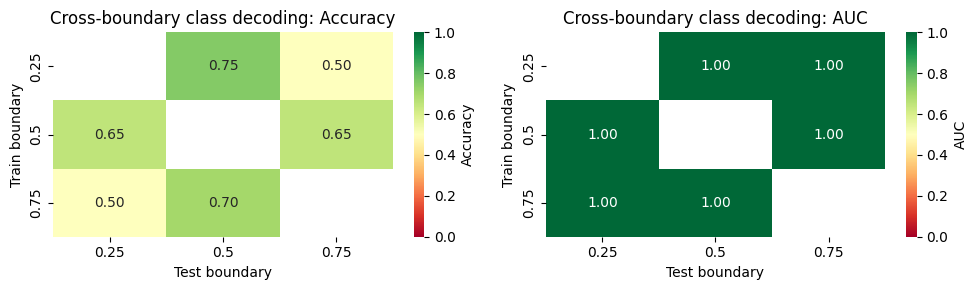

   train_bound  test_bound   acc  auc  n_train  n_test
0         0.25        0.50  0.75  1.0       20      20
1         0.25        0.75  0.50  1.0       20      20
2         0.50        0.25  0.65  1.0       20      20
3         0.50        0.75  0.65  1.0       20      20
4         0.75        0.25  0.50  1.0       20      20
5         0.75        0.50  0.70  1.0       20      20


In [12]:
# Visualize cross-decoding matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Accuracy matrix
acc_matrix = cross_decoding_df.pivot(index='train_bound', columns='test_bound', values='acc')
sns.heatmap(acc_matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[0], cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Cross-boundary class decoding: Accuracy')
axes[0].set_xlabel('Test boundary')
axes[0].set_ylabel('Train boundary')

# AUC matrix
auc_matrix = cross_decoding_df.pivot(index='train_bound', columns='test_bound', values='auc')
sns.heatmap(auc_matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[1], cbar_kws={'label': 'AUC'})
axes[1].set_title('Cross-boundary class decoding: AUC')
axes[1].set_xlabel('Test boundary')
axes[1].set_ylabel('Train boundary')

plt.tight_layout()
plt.show()

print(cross_decoding_df)

### relating neural and behavioral measures